Dataset Shape
(35000, 25)
  UserID  Year     Month  Age Occupation  FamilySize CityType  MonthlyIncome  \
0  U0001  2020  February   35    Teacher           3    Urban       74318.22   
1  U0001  2020     March   35    Teacher           3    Urban       74753.15   
2  U0001  2020     April   35    Teacher           3    Urban       75243.88   
3  U0001  2020       May   35    Teacher           3    Urban       75293.65   
4  U0001  2020      June   35    Teacher           3    Urban       75340.94   

       Rent  Groceries  ...  Shopping  SubscriptionCount  SubscriptionCost  \
0  13573.22   32337.26  ...  10900.52                  4              4272   
1  14730.92   24738.25  ...  11374.63                  4              8040   
2  18292.14   37352.87  ...   8717.94                  4              5684   
3  17493.10   39924.16  ...   9652.54                  4              9724   
4  16376.44   32646.45  ...   6032.24                  4              8220   

   EMI_Loan  Investment 

/var/folders/jt/vsg65f511y5b1c5sqvy43rvh0000gn/T/ipykernel_1595/438452212.py:54: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

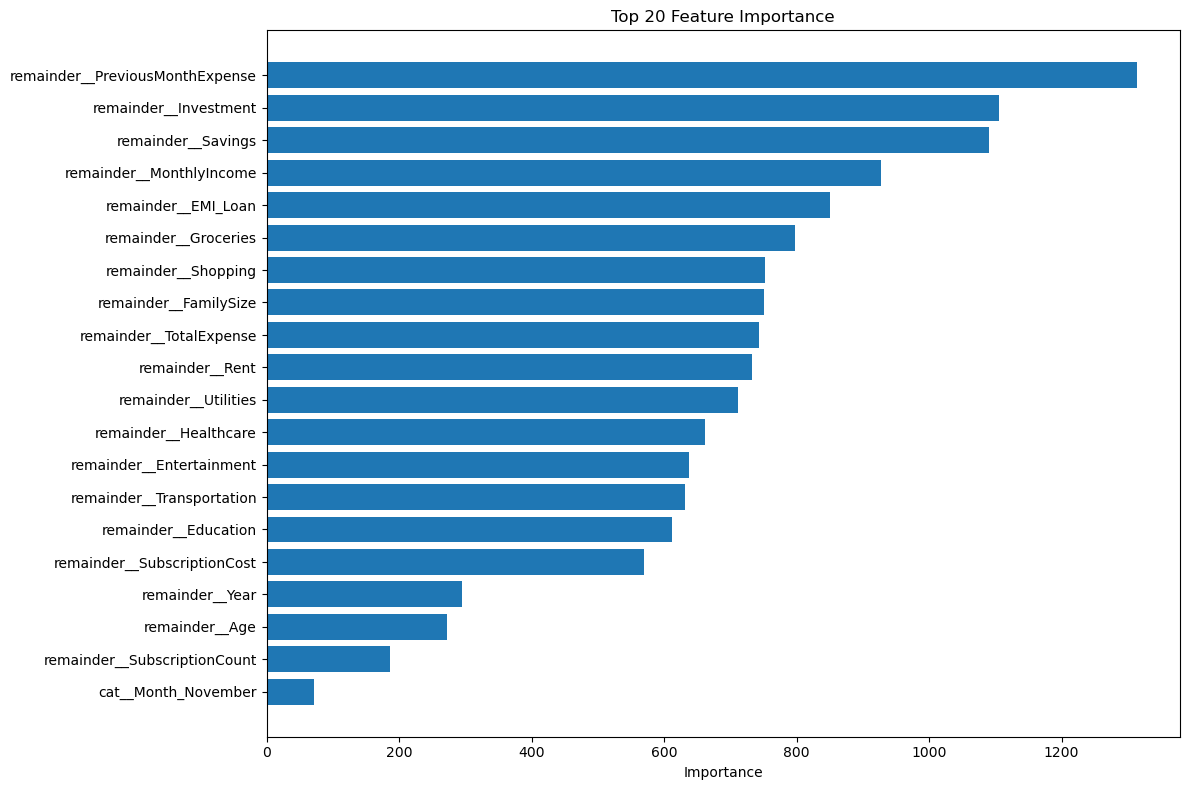

Model Saved Successfully


In [6]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


df = pd.read_csv("expense_prediction_dataset.csv")

print("Dataset Shape")
print(df.shape)


print(df.head())

print(df.info())


# Missing Values


print("Missing Values")
print(df.isnull().sum())

# Target Variable

target = "NextMonthExpense"

X = df.drop(columns=[target])

y = df[target]

# Categorical & Numerical Columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("\nCategorical Features")
print(categorical_features)

print("\nNumerical Features")
print(numerical_features)

# Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


model = LGBMRegressor(
    objective="regression",
    boosting_type="gbdt",

    n_estimators=500,
    learning_rate=0.05,

    num_leaves=31,

    max_depth=8,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42
)


# Pipeline

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])


# Train Model

print("Training Model...")

pipeline.fit(X_train, y_train)

print("Training Completed")


# Prediction

predictions = pipeline.predict(X_test)


# Evaluation

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)


print("Evaluation")

print(f"MAE  : {mae:.2f}")

print(f"MSE  : {mse:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R² Score : {r2:.4f}")


# Cross Validation

print("Cross Validation")

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print("Fold Scores")

print(scores)

print("Average R²")

print(scores.mean())


# Feature Importance

print("Generating Feature Importance")

pipeline.fit(X, y)

encoder = pipeline.named_steps["preprocessor"]

encoded_names = encoder.get_feature_names_out()

importance = pipeline.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": encoded_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(20))

plt.figure(figsize=(12,8))

plt.barh(
    feature_importance["Feature"][:20][::-1],
    feature_importance["Importance"][:20][::-1]
)

plt.title("Top 20 Feature Importance")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()


# Save Model


joblib.dump(
    pipeline,
    "lightgbm_expense_prediction_model.pkl"
)


print("Model Saved Successfully")





In [7]:
# Predict New Data

sample = pd.DataFrame({

    "UserID":["U00001"],

    "Year":[2026],

    "Month":["July"],

    "Age":[30],

    "Occupation":["Engineer"],

    "FamilySize":[4],

    "CityType":["Urban"],

    "MonthlyIncome":[150000],

    "Rent":[30000],

    "Groceries":[22000],

    "Transportation":[8000],

    "Utilities":[5000],

    "Healthcare":[4000],

    "Education":[12000],

    "Entertainment":[5000],

    "Shopping":[8000],

    "SubscriptionCount":[3],

    "SubscriptionCost":[2500],

    "EMI_Loan":[15000],

    "Investment":[12000],

    "Savings":[25000],

    "PreviousMonthExpense":[115000],

    "FestivalMonth":[0],

    "TotalExpense":[110000]

})

prediction = pipeline.predict(sample)

print("Predicted Next Month Expense")

print(prediction[0])
    


Predicted Next Month Expense
148464.65664249932
